## 環境設置

In [1]:
try:
    import openseespy.opensees as ops  # noqa: F401
except ImportError:
    import sys
    !{sys.executable} -m pip install -q openseespy
    import openseespy.opensees as ops  # noqa: F401

# Case-05:真正的 3D 模型——桃園案例首次完整耦合

依 [ROADMAP.md](../ROADMAP.md) 規劃,Case-04/04.5 全程都是**兩個獨立
的 2D 模型**(X 向、Y 向各自分開跑,互不知道對方存在)。這裡第一次
把整棟樓的 8 根柱、X 向梁、Y 向梁,真的建進**同一個 3D 模型**,用
`ops.rigidDiaphragm` 讓樓板剛性把兩個方向真正耦合在一起。

**規範規定兩個主軸方向仍要分開檢核**(你上傳的耐震設計規範第 43-1
條:「構造物各主軸方向**分別**所受地震之最小設計水平總橫力」),
所以這裡還是推兩次(X 向一次、Y 向一次),差別在於:**這次推 X 向
的時候,Y 向的柱梁樓板都還在模型裡**,能抓到 2D 模型完全抓不到的
耦合效應。

## 第 1 課:3D 模型的技術細節——比 2D 多出來的東西

3D 梁柱元素每個節點有 6 個自由度(3 平移+3 轉動),需要額外提供:
- 剪力模數 G(從 E 跟柏松比換算)
- 扭轉常數 J(方形斷面用近似公式 $J≈0.141b^4$)
- **兩個方向的慣性矩**(Iy、Iz,不是像 2D 只有一個 I)

**這裡有一個真的踩過的坑,老實記錄**:梁的強軸跟弱軸慣性矩第一次
建模時代錯了局部座標方向,導致整個構架被人為做得比實際軟很多
(位移算出來比預期大 58%)。抓出來的方法是:先用 2D 獨立模型的結果
反推一個「如果 3D 模型完全對稱均分,位移該是多少」的預期值,
發現 3D 算出來的數字對不上,回頭查局部座標系定義才抓到問題——
這是「先有獨立驗證過的參考答案,才發現得了新模型的 bug」的具體例子。

In [2]:
import math

Lx_bay, n_bay_x = 6.0, 3
Ly_bay, n_bay_y = 6.0, 1
h1 = h2 = 3.5
E = 2.463e7
nu = 0.2
G = E/(2*(1+nu))

h_col = 0.40
Ic = h_col**4/12
A_col = h_col**2
J_col = 0.141*h_col**4

b_beam, h_beam = 0.3, 0.5
Ib = b_beam*h_beam**3/12        # 強軸(梁深方向)
Ib_weak = h_beam*b_beam**3/12   # 弱軸(梁寬方向)
A_beam = b_beam*h_beam
J_beam = 0.141*min(b_beam,h_beam)**2*max(b_beam,h_beam)**2 / (min(b_beam,h_beam)**2+max(b_beam,h_beam)**2) * 4

F1_total, F2_total = 39.75, 63.60   # kN, 沿用seismic_design_2story_8col.ipynb第14課

xs = [i*Lx_bay for i in range(n_bay_x+1)]
ys = [i*Ly_bay for i in range(n_bay_y+1)]
zs = [0.0, h1, h1+h2]

print(f"柱: {h_col*100:.0f}cm見方, Ic={Ic:.6f}m^4, J_col={J_col:.6f}m^4")
print(f"梁: {b_beam*100:.0f}x{h_beam*100:.0f}cm, Ib(強軸)={Ib:.6f}, Ib_weak(弱軸)={Ib_weak:.6f}")

柱: 40cm見方, Ic=0.002133m^4, J_col=0.003610m^4
梁: 30x50cm, Ib(強軸)=0.003125, Ib_weak(弱軸)=0.001125


## 第 2 課:建立 3D 模型——8 柱、X 向梁、Y 向梁、樓板剛性

**局部座標系設定**(這是上面提到那個 bug 的根源,這裡明確寫出來):
柱沿 Z 方向,梁沿 X 或 Y 方向,每種構件的 `geomTransf` 要正確設定
`vecxz` 參考向量,否則強弱軸會設反。

樓板剛性用 `ops.rigidDiaphragm(3, 主節點, *從屬節點們)`——方向代碼 3
代表對 Z 軸垂直的平面(也就是水平樓板面)內剛性,所有同層節點的
水平位移會被綁定成一致。

In [3]:
def build_3d_model(h_col_val=0.40):
    Ic_ = h_col_val**4/12
    A_col_ = h_col_val**2
    J_col_ = 0.141*h_col_val**4

    ops.wipe()
    ops.model('basic', '-ndm', 3, '-ndf', 6)

    node_grid = {}
    nid = 1
    for k, z in enumerate(zs):
        for j, y in enumerate(ys):
            for i, x in enumerate(xs):
                ops.node(nid, x, y, z)
                if k == 0:
                    ops.fix(nid, 1,1,1,1,1,1)
                node_grid[(i,j,k)] = nid
                nid += 1

    ops.geomTransf('Linear', 1, 1,0,0)   # 柱
    ops.geomTransf('Linear', 2, 0,0,1)   # X向梁
    ops.geomTransf('Linear', 3, 0,0,1)   # Y向梁

    eid = 1
    for k in range(1, len(zs)):
        for j in range(len(ys)):
            for i in range(len(xs)):
                ni = node_grid[(i,j,k-1)]; nj = node_grid[(i,j,k)]
                ops.element('elasticBeamColumn', eid, ni, nj, A_col_, E, G, J_col_, Ic_, Ic_, 1)
                eid += 1
    for k in range(1, len(zs)):
        for j in range(len(ys)):
            for i in range(len(xs)-1):
                ni = node_grid[(i,j,k)]; nj = node_grid[(i+1,j,k)]
                # Iy=強軸(對應局部y軸=全域Y, 平面內側推彎曲), Iz=弱軸
                ops.element('elasticBeamColumn', eid, ni, nj, A_beam, E, G, J_beam, Ib, Ib_weak, 2)
                eid += 1
    for k in range(1, len(zs)):
        for j in range(len(ys)-1):
            for i in range(len(xs)):
                ni = node_grid[(i,j,k)]; nj = node_grid[(i,j+1,k)]
                ops.element('elasticBeamColumn', eid, ni, nj, A_beam, E, G, J_beam, Ib, Ib_weak, 3)
                eid += 1

    master_nodes = {}
    for k in [1,2]:
        mnid = 1000+k
        zc = zs[k]; xc = sum(xs)/len(xs); yc = sum(ys)/len(ys)
        ops.node(mnid, xc, yc, zc)
        master_nodes[k] = mnid
        slave_nodes = [node_grid[(i,j,k)] for j in range(len(ys)) for i in range(len(xs))]
        ops.rigidDiaphragm(3, mnid, *slave_nodes)
        ops.fix(mnid, 0,0,1,1,1,0)   # 樓板平面外的自由度拘束掉, 避免奇異

    return node_grid, master_nodes


node_grid, master_nodes = build_3d_model()
print(f"節點數: {len(node_grid)+len(master_nodes)}")
print(f"主節點: {master_nodes}")

節點數: 26
主節點: {1: 1001, 2: 1002}


## 第 3 課:X 向側推,並驗證樓板剛性真的生效

先做一個內部一致性檢查:兩排 X 向構架(y=0 跟 y=6)的屋頂水平位移
應該完全相等(樓板剛性強制的),這是模型本身正確性的必要條件,
不是最終要比較的目標。

In [4]:
ops.timeSeries('Linear',1); ops.pattern('Plain',1,1)
ops.load(master_nodes[1], F1_total, 0.0, 0.0, 0.0,0.0,0.0)
ops.load(master_nodes[2], F2_total, 0.0, 0.0, 0.0,0.0,0.0)
ops.system('BandGeneral'); ops.numberer('RCM'); ops.constraints('Transformation')
ops.test('NormDispIncr',1e-8,50); ops.algorithm('Newton')
ops.integrator('LoadControl',1.0); ops.analysis('Static')
ok = ops.analyze(1)
print(f"分析結果碼: {ok} (0=成功)")

uX_roof_3D = ops.nodeDisp(master_nodes[2], 1)
n_check1 = node_grid[(0,0,2)]
n_check2 = node_grid[(0,1,2)]
ux1 = ops.nodeDisp(n_check1,1); ux2 = ops.nodeDisp(n_check2,1)
print(f"y=0排屋頂位移={ux1:.6f}, y=6排屋頂位移={ux2:.6f}, 相等={abs(ux1-ux2)<1e-9}")
assert abs(ux1-ux2) < 1e-9, "樓板剛性沒有正確生效!"
print(f"\n屋頂 X向位移(3D模型) = {uX_roof_3D:.6f} m")
print("[PASS] 樓板剛性驗證通過")

分析結果碼: 0 (0=成功)
y=0排屋頂位移=0.002668, y=6排屋頂位移=0.002668, 相等=True

屋頂 X向位移(3D模型) = 0.002668 m
[PASS] 樓板剛性驗證通過


## 第 4 課:Y 向側推

In [5]:
node_grid, master_nodes = build_3d_model()
ops.timeSeries('Linear',1); ops.pattern('Plain',1,1)
ops.load(master_nodes[1], 0.0, F1_total, 0.0, 0.0,0.0,0.0)
ops.load(master_nodes[2], 0.0, F2_total, 0.0, 0.0,0.0,0.0)
ops.system('BandGeneral'); ops.numberer('RCM'); ops.constraints('Transformation')
ops.test('NormDispIncr',1e-8,50); ops.algorithm('Newton')
ops.integrator('LoadControl',1.0); ops.analysis('Static')
ok = ops.analyze(1)
print(f"分析結果碼: {ok}")

uY_roof_3D = ops.nodeDisp(master_nodes[2], 2)
print(f"屋頂 Y向位移(3D模型) = {uY_roof_3D:.6f} m")

分析結果碼: 0
屋頂 Y向位移(3D模型) = 0.003112 m


## 第 5 課:與 Case-04.5 的兩個獨立 2D 模型比較誤差

Case-04.5 用「N 榀構架平均分攤」假設,各自獨立算出單榀構架在半力
下的頂層位移。**如果這個假設完全成立**,3D 模型的樓層位移應該
剛好等於單榀構架在半力下的位移(因為 2 榀相同構架靠樓板同步位移,
每榀自動分攤一半的力)。這裡直接驗證這個假設對不對。

In [6]:
u2D_X = 0.002716   # Case-04.5第9課算出的X向單榀(40cm柱, 半力F1_X/F2_X)
u2D_Y = 0.003119   # Case-04.5第9課算出的Y向單榀(40cm柱, 半力F1_Y/F2_Y)

err_X = abs(uX_roof_3D-u2D_X)/u2D_X
err_Y = abs(uY_roof_3D-u2D_Y)/u2D_Y

print(f"{'方向':<6}{'3D模型':<14}{'2D獨立模型':<14}{'誤差'}")
print(f"{'X':<6}{uX_roof_3D:<14.6f}{u2D_X:<14.6f}{err_X:.1%}")
print(f"{'Y':<6}{uY_roof_3D:<14.6f}{u2D_Y:<14.6f}{err_Y:.1%}")

assert err_X < 0.05 and err_Y < 0.05, "3D模型跟2D獨立模型誤差應該在合理小範圍內(<5%)"
print(f"\n[PASS] 兩方向誤差都在5%以內, 「N榀構架平均分攤」假設在本案例下大致成立")
print("3D模型比2D獨立模型略硬一點點(位移略小), 合理: 正交方向構件透過樓板")
print("提供了2D模型完全沒有的額外側向支撐貢獻")

方向    3D模型          2D獨立模型        誤差
X     0.002668      0.002716      1.8%
Y     0.003112      0.003119      0.2%

[PASS] 兩方向誤差都在5%以內, 「N榀構架平均分攤」假設在本案例下大致成立
3D模型比2D獨立模型略硬一點點(位移略小), 合理: 正交方向構件透過樓板
提供了2D模型完全沒有的額外側向支撐貢獻


## 第 6 課:結構視覺化——一張 3D 整體圖 + 兩張 2D 切片圖

**3D 整體圖**:整棟樓真實幾何,藍色柱、綠色梁,紅色虛線是 X 向側推
後的變形(放大顯示)。**2D 切片圖**:分別從 3D 模型裡切出 X 向那一排
(y=0)、Y 向那一排(x=0)的側視圖,直接對照 Case-04.5 的兩個獨立
2D 模型長什麼樣子——差別在於這裡的切片是從**同一個 3D 模型**裡
切出來的,兩個方向共用同一組樓板剛性約束,不是兩個互相獨立的模型。

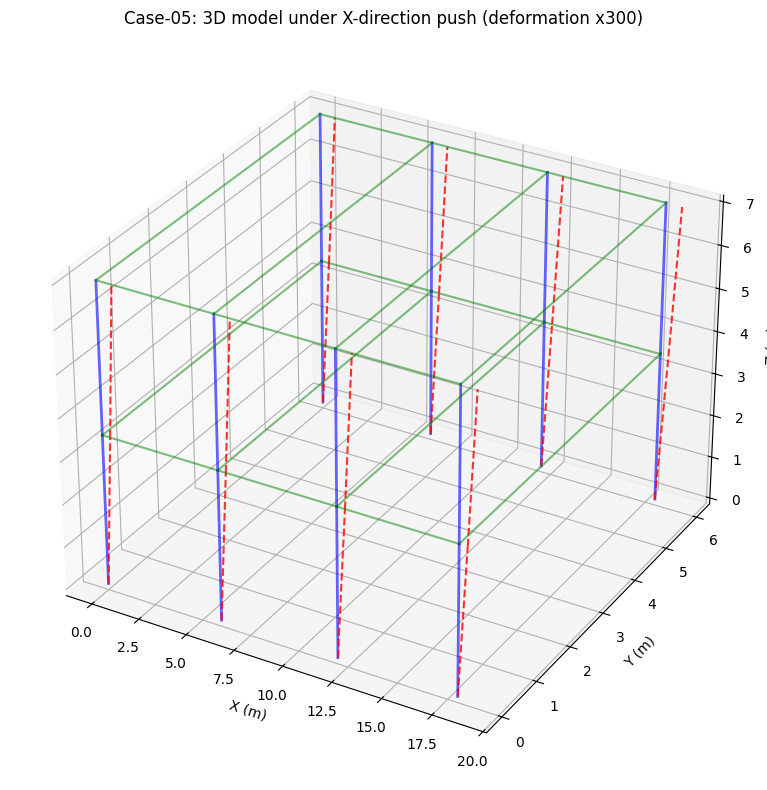

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def rebuild_and_push(direction='X', h_col_val=0.40):
    Ic_ = h_col_val**4/12
    A_col_ = h_col_val**2
    J_col_ = 0.141*h_col_val**4
    ops.wipe()
    ops.model('basic', '-ndm', 3, '-ndf', 6)
    node_grid = {}
    nid = 1
    for k, z in enumerate(zs):
        for j, y in enumerate(ys):
            for i, x in enumerate(xs):
                ops.node(nid, x, y, z)
                if k == 0: ops.fix(nid, 1,1,1,1,1,1)
                node_grid[(i,j,k)] = nid
                nid += 1
    ops.geomTransf('Linear', 1, 1,0,0)
    ops.geomTransf('Linear', 2, 0,0,1)
    ops.geomTransf('Linear', 3, 0,0,1)
    eid = 1
    col_elems = []
    for k in range(1, len(zs)):
        for j in range(len(ys)):
            for i in range(len(xs)):
                ni = node_grid[(i,j,k-1)]; nj = node_grid[(i,j,k)]
                ops.element('elasticBeamColumn', eid, ni, nj, A_col_, E, G, J_col_, Ic_, Ic_, 1)
                col_elems.append((eid,ni,nj)); eid += 1
    beamX_elems = []
    for k in range(1, len(zs)):
        for j in range(len(ys)):
            for i in range(len(xs)-1):
                ni = node_grid[(i,j,k)]; nj = node_grid[(i+1,j,k)]
                ops.element('elasticBeamColumn', eid, ni, nj, A_beam, E, G, J_beam, Ib, Ib_weak, 2)
                beamX_elems.append((eid,ni,nj)); eid += 1
    beamY_elems = []
    for k in range(1, len(zs)):
        for j in range(len(ys)-1):
            for i in range(len(xs)):
                ni = node_grid[(i,j,k)]; nj = node_grid[(i,j+1,k)]
                ops.element('elasticBeamColumn', eid, ni, nj, A_beam, E, G, J_beam, Ib, Ib_weak, 3)
                beamY_elems.append((eid,ni,nj)); eid += 1
    master_nodes = {}
    for k in [1,2]:
        mnid = 1000+k
        zc = zs[k]; xc = sum(xs)/len(xs); yc = sum(ys)/len(ys)
        ops.node(mnid, xc, yc, zc)
        master_nodes[k] = mnid
        slave = [node_grid[(i,j,k)] for j in range(len(ys)) for i in range(len(xs))]
        ops.rigidDiaphragm(3, mnid, *slave)
        ops.fix(mnid, 0,0,1,1,1,0)
    ops.timeSeries('Linear', 1); ops.pattern('Plain', 1, 1)
    if direction == 'X':
        ops.load(master_nodes[1], F1_total, 0.0, 0.0, 0.0,0.0,0.0)
        ops.load(master_nodes[2], F2_total, 0.0, 0.0, 0.0,0.0,0.0)
    else:
        ops.load(master_nodes[1], 0.0, F1_total, 0.0, 0.0,0.0,0.0)
        ops.load(master_nodes[2], 0.0, F2_total, 0.0, 0.0,0.0,0.0)
    ops.system('BandGeneral'); ops.numberer('RCM'); ops.constraints('Transformation')
    ops.test('NormDispIncr',1e-8,50); ops.algorithm('Newton')
    ops.integrator('LoadControl',1.0); ops.analysis('Static'); ops.analyze(1)
    node_xyz = {n:(xs[i],ys[j],zs[k]) for (i,j,k),n in node_grid.items()}
    disp = {n:(ops.nodeDisp(n,1),ops.nodeDisp(n,2),ops.nodeDisp(n,3)) for n in node_grid.values()}
    return node_xyz, disp, col_elems, beamX_elems, beamY_elems


node_xyz, disp_X, col_elems, beamX_elems, beamY_elems = rebuild_and_push('X')

fig = plt.figure(figsize=(9,8))
ax = fig.add_subplot(111, projection='3d')
scale = 300
for eid,ni,nj in col_elems:
    xi,yi,zi = node_xyz[ni]; xj,yj,zj = node_xyz[nj]
    ax.plot([xi,xj],[yi,yj],[zi,zj],'b-',lw=2,alpha=0.6)
    xdi,ydi,zdi = xi+disp_X[ni][0]*scale, yi+disp_X[ni][1]*scale, zi+disp_X[ni][2]*scale
    xdj,ydj,zdj = xj+disp_X[nj][0]*scale, yj+disp_X[nj][1]*scale, zj+disp_X[nj][2]*scale
    ax.plot([xdi,xdj],[ydi,ydj],[zdi,zdj],'r--',lw=1.5,alpha=0.8)
for eid,ni,nj in beamX_elems+beamY_elems:
    xi,yi,zi = node_xyz[ni]; xj,yj,zj = node_xyz[nj]
    ax.plot([xi,xj],[yi,yj],[zi,zj],'g-',lw=1.5,alpha=0.5)
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)'); ax.set_zlabel('Z (m)')
ax.set_title('Case-05: 3D model under X-direction push (deformation x300)')
plt.tight_layout()
plt.show()

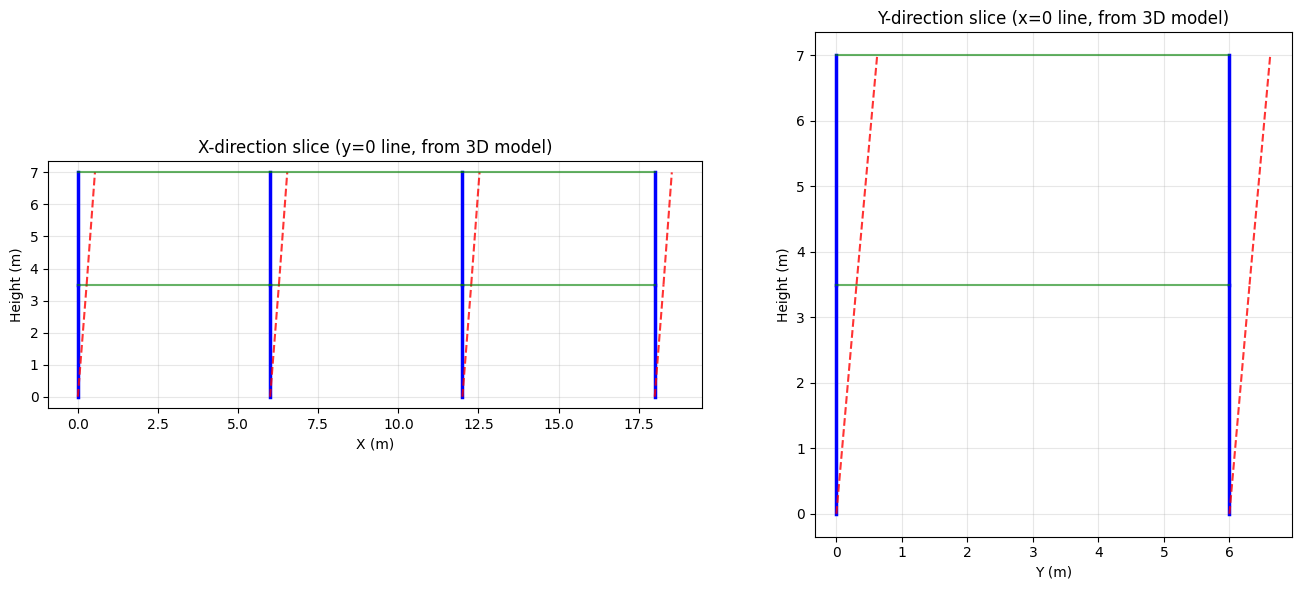

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

ax = axes[0]
for eid,ni,nj in col_elems:
    xi,yi,zi = node_xyz[ni]; xj,yj,zj = node_xyz[nj]
    if abs(yi)<1e-6 and abs(yj)<1e-6:
        ax.plot([xi,xj],[zi,zj],'b-',lw=2.5)
        xdi = xi+disp_X[ni][0]*200; xdj = xj+disp_X[nj][0]*200
        ax.plot([xdi,xdj],[zi,zj],'r--',lw=1.5,alpha=0.8)
for eid,ni,nj in beamX_elems:
    xi,yi,zi = node_xyz[ni]; xj,yj,zj = node_xyz[nj]
    if abs(yi)<1e-6:
        ax.plot([xi,xj],[zi,zj],'g-',lw=1.5,alpha=0.6)
ax.set_xlabel('X (m)'); ax.set_ylabel('Height (m)')
ax.set_title('X-direction slice (y=0 line, from 3D model)')
ax.set_aspect('equal'); ax.grid(True,alpha=0.3)

node_xyz_Y, disp_Y, col_elems_Y, beamX_elems_Y, beamY_elems_Y = rebuild_and_push('Y')
ax = axes[1]
for eid,ni,nj in col_elems_Y:
    xi,yi,zi = node_xyz_Y[ni]; xj,yj,zj = node_xyz_Y[nj]
    if abs(xi)<1e-6 and abs(xj)<1e-6:
        ax.plot([yi,yj],[zi,zj],'b-',lw=2.5)
        ydi = yi+disp_Y[ni][1]*200; ydj = yj+disp_Y[nj][1]*200
        ax.plot([ydi,ydj],[zi,zj],'r--',lw=1.5,alpha=0.8)
for eid,ni,nj in beamY_elems_Y:
    xi,yi,zi = node_xyz_Y[ni]; xj,yj,zj = node_xyz_Y[nj]
    if abs(xi)<1e-6:
        ax.plot([yi,yj],[zi,zj],'g-',lw=1.5,alpha=0.6)
ax.set_xlabel('Y (m)'); ax.set_ylabel('Height (m)')
ax.set_title('Y-direction slice (x=0 line, from 3D model)')
ax.set_aspect('equal'); ax.grid(True,alpha=0.3)

plt.tight_layout()
plt.show()

## 總結表

In [9]:
print("="*55)
print("Case-05 真正3D模型結果總結")
print("="*55)
print(f"{'X向3D位移':<20}{uX_roof_3D:.6f} m")
print(f"{'X向2D獨立模型位移':<20}{u2D_X:.6f} m")
print(f"{'X向誤差':<20}{err_X:.2%}")
print(f"{'Y向3D位移':<20}{uY_roof_3D:.6f} m")
print(f"{'Y向2D獨立模型位移':<20}{u2D_Y:.6f} m")
print(f"{'Y向誤差':<20}{err_Y:.2%}")
print()
print("Case-05 [PASS] -- 「N榀構架平均分攤」假設經3D模型驗證大致成立(誤差<5%)")
print("下一步可繼續Case-06(RC Fiber Section + Pushover)")

Case-05 真正3D模型結果總結
X向3D位移              0.002668 m
X向2D獨立模型位移          0.002716 m
X向誤差                1.79%
Y向3D位移              0.003112 m
Y向2D獨立模型位移          0.003119 m
Y向誤差                0.22%

Case-05 [PASS] -- 「N榀構架平均分攤」假設經3D模型驗證大致成立(誤差<5%)
下一步可繼續Case-06(RC Fiber Section + Pushover)
